# AI-Powered Bank Deposit Subscription Prediction System

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import pickle

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("bank.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Step 3: Data Understanding

In [3]:
df.shape

(11162, 17)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [7]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

## Step 4: Exploratory Data Analysis (EDA)
### Target Variable Distribution

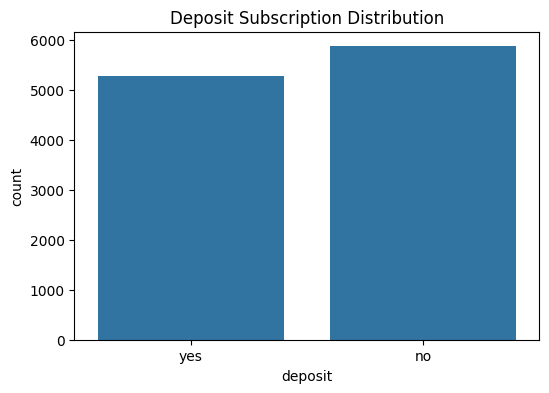

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df)
plt.title("Deposit Subscription Distribution")
plt.show()

### Job Distribution

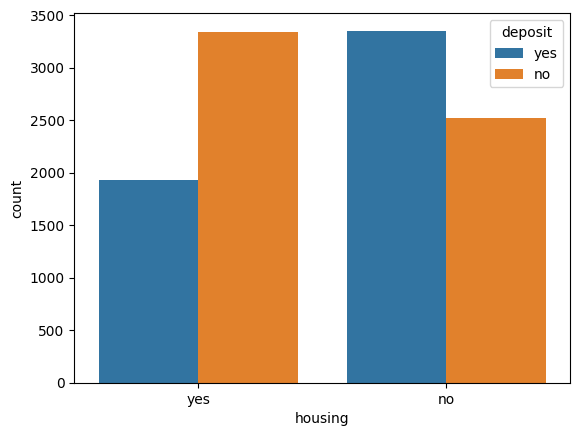

In [9]:
sns.countplot(
    x='housing',
    hue='deposit',
    data=df
)
plt.show()

### Age Distribution

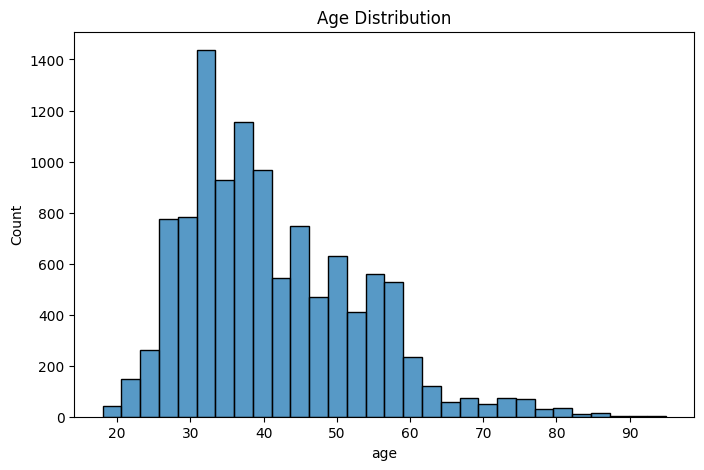

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

### Balance Distribution

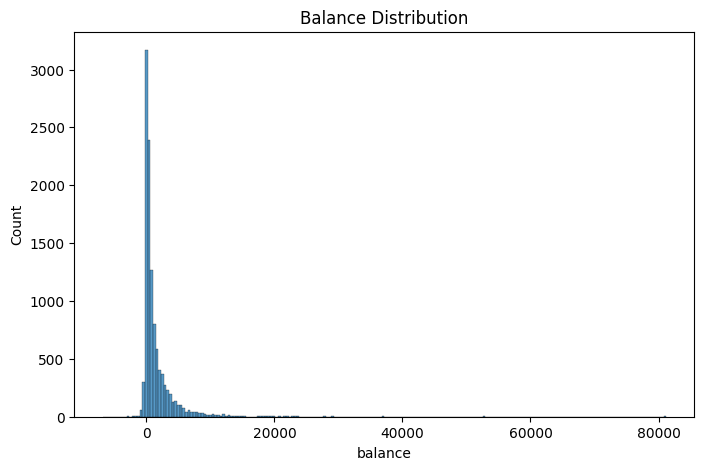

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['balance'])
plt.title("Balance Distribution")
plt.show()

### Deposit vs Housing Loan

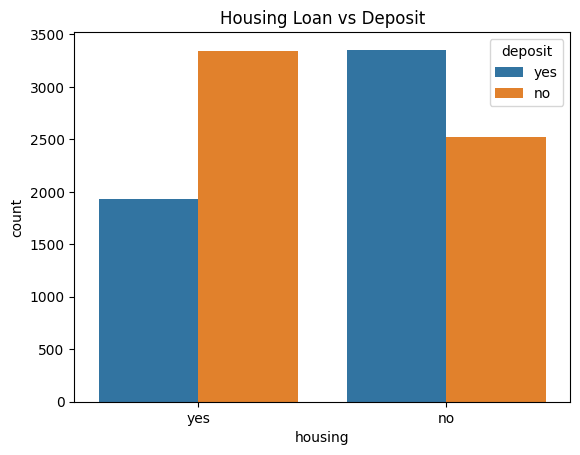

In [12]:
sns.countplot(
    x='housing',
    hue='deposit',
    data=df
)

plt.title("Housing Loan vs Deposit")

plt.show()

## Step 5: Data Preprocessing
### Label Encoding

In [13]:
le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == 'object':
        
        df[col] = le.fit_transform(df[col])

## Step 6: Correlation Matrix

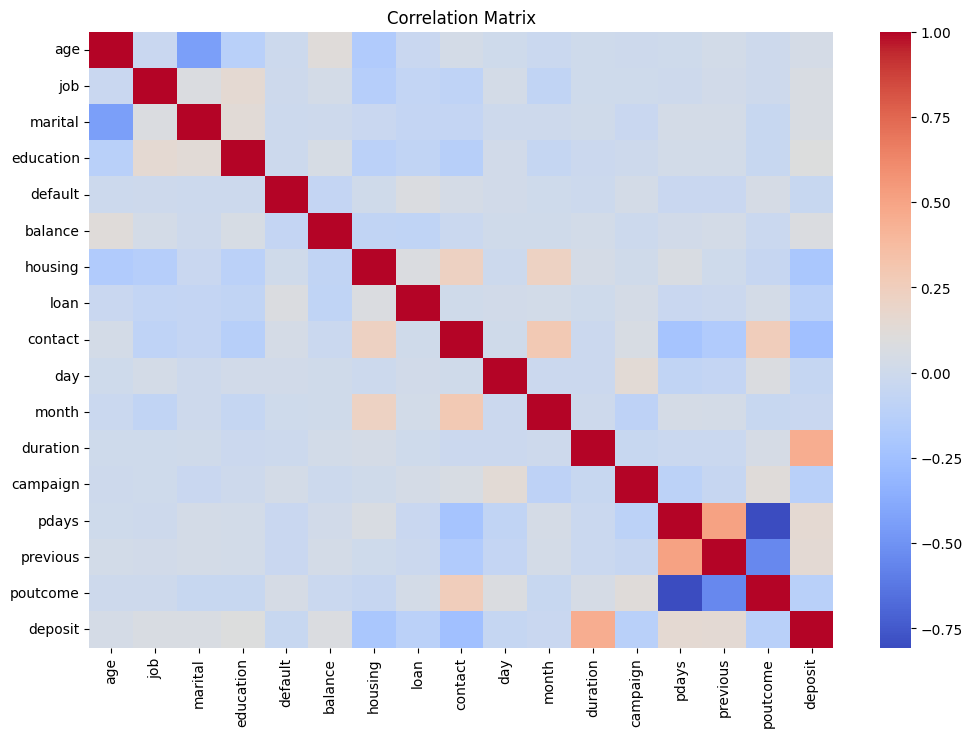

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## Step 7: Feature & Target

In [15]:
X = df.drop("deposit", axis=1)

y = df["deposit"]

## Step 8: Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    random_state=42
    
)

## Step 9: Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 10: Logistic Regression

In [18]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

### Evaluation

In [19]:
print("Accuracy:",
      accuracy_score(y_test,pred_lr))

print(confusion_matrix(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy: 0.7487684729064039
[[911 255]
 [306 761]]
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1166
           1       0.75      0.71      0.73      1067

    accuracy                           0.75      2233
   macro avg       0.75      0.75      0.75      2233
weighted avg       0.75      0.75      0.75      2233



## Step 11: Random Forest

In [20]:
rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

### Evaluation

In [21]:
print("Accuracy:",
      accuracy_score(y_test,pred_rf))

print(confusion_matrix(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Accuracy: 0.8365427675772503
[[952 214]
 [151 916]]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.86      0.83      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



## ROC AUC Score

In [22]:
rf_prob = rf.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", round(auc,4))

ROC-AUC Score: 0.4495


## Step 12: Feature Importance

In [23]:
importance = pd.DataFrame({
    
    'Feature':X.columns,
    'Importance':rf.feature_importances_
    
})

importance = importance.sort_values(
    
    by='Importance',
    ascending=False
    
)

importance.head(10)

,Feature,Importance
11,duration,0.373688
5,balance,0.086340
0,age,0.082483
10,month,0.082430
9,day,0.071160
8,contact,0.046148
13,pdays,0.044356
1,job,0.038299
15,poutcome,0.034495
12,campaign,0.033597


### Visualization

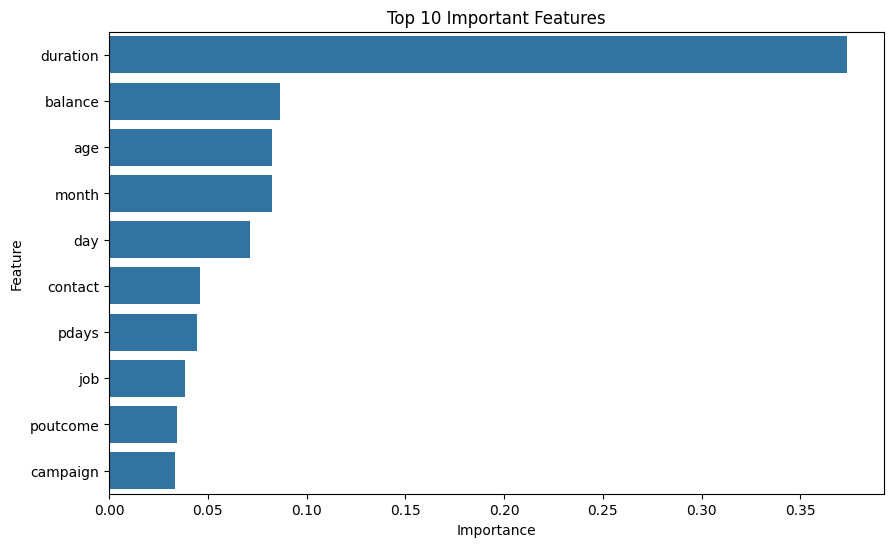

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance.head(10)

)

plt.title("Top 10 Important Features")

plt.show()

## Step 13: Save Model

In [25]:
pickle.dump(

    rf,

    open("bank_deposit_model.pkl", "wb")

)

## Step 14: Save Scaler

In [26]:
pickle.dump(

    scaler,

    open("scaler.pkl", "wb")

)

## Step 15: Customer Prediction System

In [27]:
sample_customer = X.iloc[[0]]

sample_customer_scaled = scaler.transform(sample_customer)

prediction = rf.predict(sample_customer_scaled)

probability = rf.predict_proba(sample_customer_scaled)

confidence = probability[0][1] * 100

## Step 16: Business Decision Engine

In [28]:
print("="*50)

print("CUSTOMER ANALYSIS REPORT")

print("="*50)

if prediction[0] == 1:
    print("Prediction : SUBSCRIBE")
else:
    print("Prediction : NOT SUBSCRIBE")

print(f"Confidence Score : {confidence:.2f}%")

if confidence >= 80:
    segment = "High Potential Customer"
elif confidence >= 60:
    segment = "Medium Potential Customer"
else:
    segment = "Low Potential Customer"

print("Customer Segment :", segment)

print("="*50)

CUSTOMER ANALYSIS REPORT
Prediction : NOT SUBSCRIBE
Confidence Score : 32.50%
Customer Segment : Low Potential Customer
